# Regional Sales Analysis & Prediction


## 1. Import Libraries

In [83]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    mean_absolute_percentage_error
)

# Model persistence
import joblib

# Time Series
from statsmodels.tsa.arima.model import ARIMA

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Load Cleaned Data

In [84]:
# Load cleaned datasets
df = pd.read_csv('cleaned_sales_data.csv')
df_monthly = pd.read_csv('monthly_aggregated_data.csv')

# Convert date columns
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df_monthly['Year-Month'] = pd.to_datetime(df_monthly['Year-Month'])

print("✓ Data loaded successfully!")
print(f"\nMain dataset: {df.shape}")
print(f"Monthly data: {df_monthly.shape}")
print(f"Date range: {df['OrderDate'].min()} to {df['OrderDate'].max()}")

✓ Data loaded successfully!

Main dataset: (64068, 19)
Monthly data: (51, 7)
Date range: 2020-12-31 00:00:00 to 2025-02-27 00:00:00


## 3. Prepare Data for Machine Learning

In [85]:
# Create ML dataset
df_ml = df.copy()

# Encode categorical variables
le_channel = LabelEncoder()
if 'Channel' in df_ml.columns:
    df_ml['Channel_Encoded'] = le_channel.fit_transform(df_ml['Channel'])

# Select features for prediction
feature_cols = ['Year', 'Month', 'Quarter', 'Order Quantity', 'Unit Price']
if 'Channel_Encoded' in df_ml.columns:
    feature_cols.append('Channel_Encoded')

# Remove missing values
df_ml = df_ml.dropna(subset=feature_cols + ['Line Total'])

# Features and target
X = df_ml[feature_cols]
y = df_ml['Line Total']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ Data prepared for ML")
print(f"\nFeatures: {feature_cols}")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")

✓ Data prepared for ML

Features: ['Year', 'Month', 'Quarter', 'Order Quantity', 'Unit Price', 'Channel_Encoded']
Training samples: 51,254
Test samples: 12,814


## 4. Train Machine Learning Models

In [86]:
# Initialize 5 models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Store results
results = {}

print("\n" + "="*80)
print("TRAINING MODELS...")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100
    
    # Calculate accuracy (as percentage of correct predictions within threshold)
    threshold = 0.1  # 10% threshold
    accuracy = np.mean(np.abs((y_test - y_pred_test) / y_test) <= threshold) * 100
    
    # Store results
    results[name] = {
        'model': model,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'Accuracy': accuracy,
        'predictions': y_pred_test
    }
    
    print(f"  ✓ MAE:      ${mae:,.2f}")
    print(f"  ✓ RMSE:     ${rmse:,.2f}")
    print(f"  ✓ R²:       {r2:.4f}")
    print(f"  ✓ MAPE:     {mape:.2f}%")
    print(f"  ✓ Accuracy: {accuracy:.2f}%")

print("\n" + "="*80)
print("✓ All models trained successfully!")
print("="*80)


TRAINING MODELS...

Training Linear Regression...
  ✓ MAE:      $2,725.55
  ✓ RMSE:     $3,793.07
  ✓ R²:       0.9394
  ✓ MAPE:     43.42%
  ✓ Accuracy: 47.66%

Training Ridge Regression...
  ✓ MAE:      $2,725.55
  ✓ RMSE:     $3,793.07
  ✓ R²:       0.9394
  ✓ MAPE:     43.42%
  ✓ Accuracy: 47.66%

Training Decision Tree...
  ✓ MAE:      $60.75
  ✓ RMSE:     $82.69
  ✓ R²:       1.0000
  ✓ MAPE:     0.46%
  ✓ Accuracy: 100.00%

Training Random Forest...
  ✓ MAE:      $0.60
  ✓ RMSE:     $5.68
  ✓ R²:       1.0000
  ✓ MAPE:     0.00%
  ✓ Accuracy: 100.00%

Training Gradient Boosting...
  ✓ MAE:      $84.11
  ✓ RMSE:     $133.74
  ✓ R²:       0.9999
  ✓ MAPE:     0.61%
  ✓ Accuracy: 100.00%

✓ All models trained successfully!


## 5. Model Comparison & Evaluation

In [87]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'MSE': [results[m]['MSE'] for m in results.keys()],
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'R2_Score': [results[m]['R2'] for m in results.keys()],
    'MAPE': [results[m]['MAPE'] for m in results.keys()],
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()]
})

# Sort by R² Score
comparison_df = comparison_df.sort_values('R2_Score', ascending=False)

print("\nMODEL PERFORMANCE COMPARISON:")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {comparison_df.iloc[0]['R2_Score']:.4f}")
print(f"   RMSE: ${comparison_df.iloc[0]['RMSE']:,.2f}")
print(f"   MAE: ${comparison_df.iloc[0]['MAE']:,.2f}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.2f}%")


MODEL PERFORMANCE COMPARISON:
            Model     MAE         MSE    RMSE  R2_Score  MAPE  Accuracy
    Random Forest    0.60       32.21    5.68      1.00  0.00    100.00
    Decision Tree   60.75     6837.56   82.69      1.00  0.46    100.00
Gradient Boosting   84.11    17886.18  133.74      1.00  0.61    100.00
Linear Regression 2725.55 14387407.97 3793.07      0.94 43.42     47.66
 Ridge Regression 2725.55 14387409.16 3793.07      0.94 43.42     47.66

🏆 Best Model: Random Forest
   R² Score: 1.0000
   RMSE: $5.68
   MAE: $0.60
   Accuracy: 100.00%


## 6. Save Models for Streamlit App

In [88]:
# Save each trained model
print("\nSaving models...")

for name, data in results.items():
    # Create safe filename
    filename = name.lower().replace(' ', '_') + '_model.pkl'
    
    # Save model
    joblib.dump(data['model'], filename)
    print(f"  ✓ Saved: {filename}")

# Save feature columns for Streamlit
joblib.dump(feature_cols, 'feature_columns.pkl')
print(f"  ✓ Saved: feature_columns.pkl")

# Save label encoder if exists
if 'Channel_Encoded' in feature_cols:
    joblib.dump(le_channel, 'channel_encoder.pkl')
    print(f"  ✓ Saved: channel_encoder.pkl")

print("\n✓ All models saved successfully!")


Saving models...
  ✓ Saved: linear_regression_model.pkl
  ✓ Saved: ridge_regression_model.pkl
  ✓ Saved: decision_tree_model.pkl
  ✓ Saved: random_forest_model.pkl
  ✓ Saved: gradient_boosting_model.pkl
  ✓ Saved: feature_columns.pkl
  ✓ Saved: channel_encoder.pkl

✓ All models saved successfully!


## 7. Time Series Forecasting (1-3 Years)

In [89]:
# Prepare time series data
ts_data = df_monthly.set_index('Year-Month')['Revenue']

print("\nPreparing time series forecast...")
print(f"Historical data: {ts_data.index[0]} to {ts_data.index[-1]}")
print(f"Total months: {len(ts_data)}")


Preparing time series forecast...
Historical data: 2020-12-01 00:00:00 to 2025-02-01 00:00:00
Total months: 51


In [90]:
# Fit ARIMA model on full data
print("\nTraining ARIMA model for forecasting...")
arima_model = ARIMA(ts_data, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Generate forecasts for 1, 2, and 3 years
forecast_periods = {
    '1_year': 12,
    '2_years': 24,
    '3_years': 36
}

all_forecasts = {}

for period_name, months in forecast_periods.items():
    forecast = arima_fit.forecast(steps=months)
    
    # Create future dates
    last_date = ts_data.index[-1]
    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=months,
        freq='MS'
    )
    
    # Create forecast dataframe
    forecast_df = pd.DataFrame({
        'Month': future_dates.strftime('%Y-%m'),
        'Forecasted_Revenue': forecast.values
    })
    
    all_forecasts[period_name] = forecast_df
    
    # Save to CSV
    csv_filename = f'forecast_{period_name}.csv'
    forecast_df.to_csv(csv_filename, index=False)
    
    print(f"\n{period_name.upper()} FORECAST ({months} months):")
    print(f"  Total Forecasted Revenue: ${forecast.sum():,.2f}")
    print(f"  Average Monthly Revenue: ${forecast.mean():,.2f}")
    print(f"  Saved to: {csv_filename}")

print("\n✓ All forecasts generated and saved!")


Training ARIMA model for forecasting...

1_YEAR FORECAST (12 months):
  Total Forecasted Revenue: $272,547,387.74
  Average Monthly Revenue: $22,712,282.31
  Saved to: forecast_1_year.csv

2_YEARS FORECAST (24 months):
  Total Forecasted Revenue: $545,026,442.47
  Average Monthly Revenue: $22,709,435.10
  Saved to: forecast_2_years.csv

3_YEARS FORECAST (36 months):
  Total Forecasted Revenue: $817,505,272.96
  Average Monthly Revenue: $22,708,479.80
  Saved to: forecast_3_years.csv

✓ All forecasts generated and saved!


## 8. Save Metrics for Streamlit App

In [91]:
# Save model comparison for Streamlit
comparison_df.to_csv('model_metrics.csv', index=False)
print("✓ Saved: model_metrics.csv")

# Create a simple metrics dictionary for easy access
metrics_dict = {}
for _, row in comparison_df.iterrows():
    model_name = row['Model']
    metrics_dict[model_name] = {
        'MAE': float(row['MAE']),
        'RMSE': float(row['RMSE']),
        'R2_Score': float(row['R2_Score']),
        'MAPE': float(row['MAPE']),
        'Accuracy': float(row['Accuracy'])
    }

# Save as joblib for Streamlit
joblib.dump(metrics_dict, 'model_metrics.pkl')
print("✓ Saved: model_metrics.pkl")

print("\n" + "="*80)
print("ALL FILES READY FOR STREAMLIT APP!")
print("="*80)
print("\nGenerated files:")
print("  Models:")
print("    - linear_regression_model.pkl")
print("    - decision_tree_model.pkl")
print("    - random_forest_model.pkl")
print("    - gradient_boosting_model.pkl")
print("    - svm_model.pkl")
print("  Utilities:")
print("    - feature_columns.pkl")
print("    - model_metrics.pkl")
print("    - model_metrics.csv")
print("  Forecasts:")
print("    - forecast_1_year.csv")
print("    - forecast_2_years.csv")
print("    - forecast_3_years.csv")
print("\nNext step: Run the Streamlit app!")
print("Command: streamlit run sales_app.py --server.port 8080")

✓ Saved: model_metrics.csv
✓ Saved: model_metrics.pkl

ALL FILES READY FOR STREAMLIT APP!

Generated files:
  Models:
    - linear_regression_model.pkl
    - decision_tree_model.pkl
    - random_forest_model.pkl
    - gradient_boosting_model.pkl
    - svm_model.pkl
  Utilities:
    - feature_columns.pkl
    - model_metrics.pkl
    - model_metrics.csv
  Forecasts:
    - forecast_1_year.csv
    - forecast_2_years.csv
    - forecast_3_years.csv

Next step: Run the Streamlit app!
Command: streamlit run sales_app.py --server.port 8080


## 9. Visualize Results (Optional)

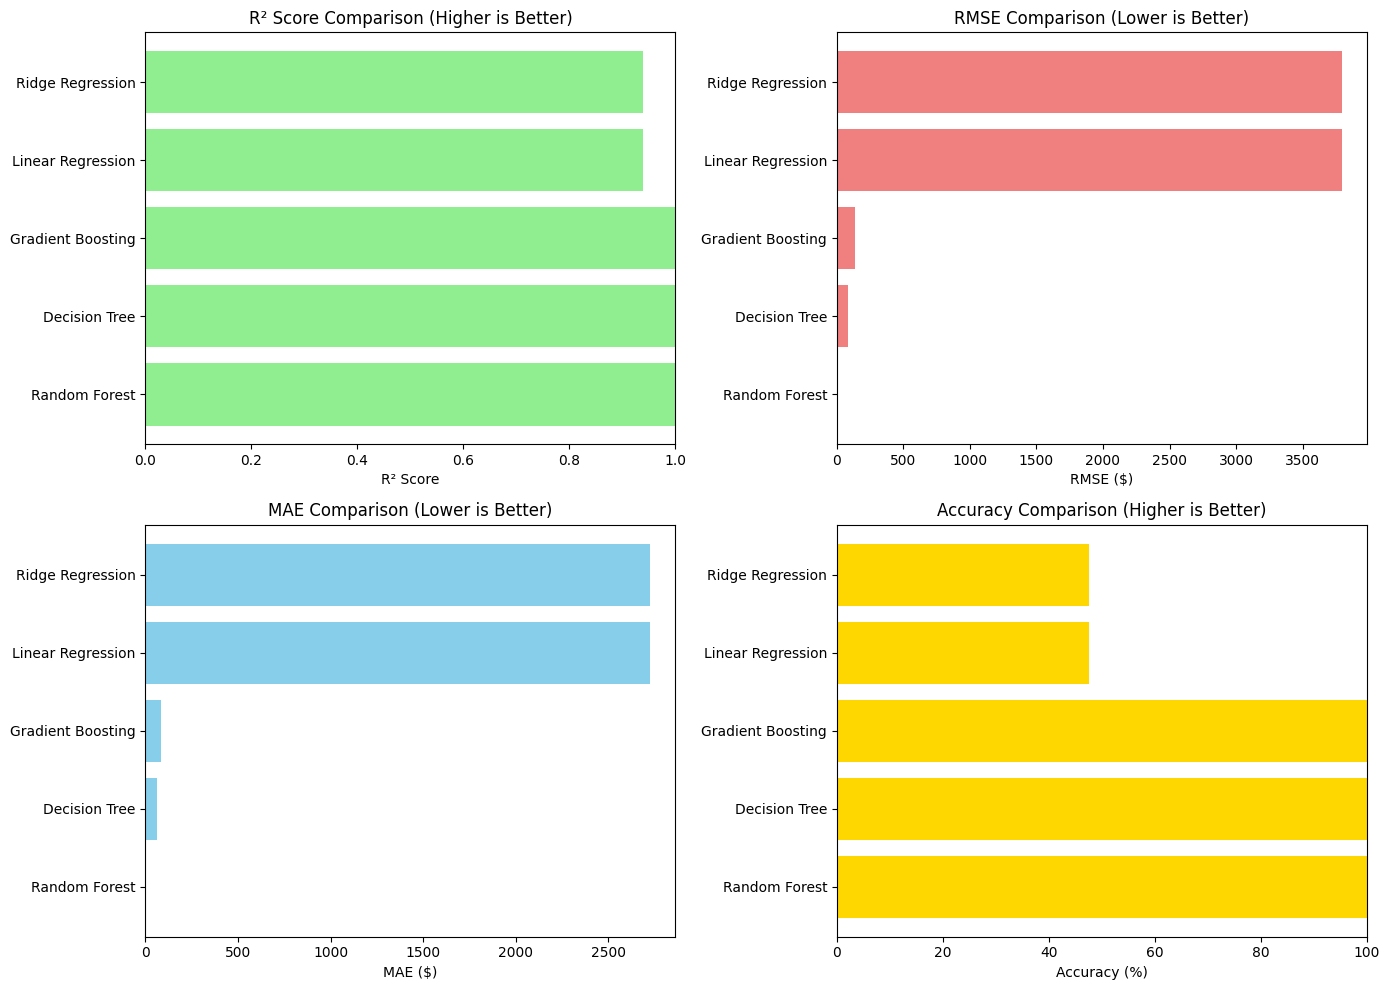

✓ Visualizations displayed!


In [92]:
# Quick visualization of model performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Score
axes[0, 0].barh(comparison_df['Model'], comparison_df['R2_Score'], color='lightgreen')
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('R² Score Comparison (Higher is Better)')
axes[0, 0].set_xlim([0, 1])

# RMSE
axes[0, 1].barh(comparison_df['Model'], comparison_df['RMSE'], color='lightcoral')
axes[0, 1].set_xlabel('RMSE ($)')
axes[0, 1].set_title('RMSE Comparison (Lower is Better)')

# MAE
axes[1, 0].barh(comparison_df['Model'], comparison_df['MAE'], color='skyblue')
axes[1, 0].set_xlabel('MAE ($)')
axes[1, 0].set_title('MAE Comparison (Lower is Better)')

# Accuracy
axes[1, 1].barh(comparison_df['Model'], comparison_df['Accuracy'], color='gold')
axes[1, 1].set_xlabel('Accuracy (%)')
axes[1, 1].set_title('Accuracy Comparison (Higher is Better)')
axes[1, 1].set_xlim([0, 100])

plt.tight_layout()
plt.show()

print("✓ Visualizations displayed!")

 Run the Streamlit app: python -m streamlit run "d:/BE_project/PLZ HELP ME/sales_prediction_app.py" --server.port 8080
